In [1]:
# Import libraries
from datasets import load_dataset
import numpy as np
import pandas as pd
import torch
from transformers import (
    AutoTokenizer, 
    AutoModelForCausalLM,
    AutoModelForSeq2SeqLM,
    T5Tokenizer,
    T5ForConditionalGeneration
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report,
    roc_curve, auc, precision_recall_curve, average_precision_score
)
import matplotlib.pyplot as plt
import seaborn as sns
import re
import random
from tqdm import tqdm
import json
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set random seeds
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

c:\ML_proj\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
class Config:
    # Data parameters
    SAMPLE_SIZE = 1000  # Match other approaches
    TEST_SIZE = 0.2
    VALIDATION_SIZE = 0.1
    RANDOM_SEED = 42
    
    # DetectGPT parameters
    MASK_FILLING_MODEL = "t5-small"  # Use t5-small for speed (paper uses t5-3b)
    SCORING_MODEL = "gpt2"  # Model to score text with
    NUM_PERTURBATIONS = 25  # Number of perturbations (paper uses 100)
    MASK_RATE = 0.15  # Fraction of words to mask
    SPAN_LENGTH = 2  # Length of masked spans
    MAX_LENGTH = 256  # Max sequence length
    BATCH_SIZE = 4  # For processing perturbations
    
    # Comparison baselines
    USE_BASELINES = True  # Compare with log p(x), rank, entropy methods
    
    # Output
    RESULTS_FILE = "detectgpt_results.json"
    PERTURBATIONS_FILE = "perturbations_sample.json"

config = Config()

In [3]:
print("📦 Loading dataset...")
dataset = load_dataset("andythetechnerd03/AI-human-text")

# Use subset
print(f"🎯 Using subset of {config.SAMPLE_SIZE} samples...")
dataset["train"] = dataset["train"].shuffle(seed=config.RANDOM_SEED).select(
    range(min(config.SAMPLE_SIZE, len(dataset["train"])))
)

# Check and rename label column
if 'label' not in dataset['train'].column_names:
    possible_label_cols = ['labels', 'target', 'class', 'category', 'generated']
    label_col = None
    for col in possible_label_cols:
        if col in dataset['train'].column_names:
            label_col = col
            break
    if label_col:
        dataset = dataset.rename_column(label_col, 'label')

print(f"Dataset size: {len(dataset['train'])}")
print(f"Sample: {dataset['train'][0]}\n")

# Split data
texts = [example['text'] for example in dataset['train']]
labels = [example['label'] for example in dataset['train']]

# Create splits
X_temp, X_test, y_temp, y_test = train_test_split(
    texts, labels, test_size=config.TEST_SIZE, 
    random_state=config.RANDOM_SEED, stratify=labels
)

val_size_adjusted = config.VALIDATION_SIZE / (1 - config.TEST_SIZE)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=val_size_adjusted, 
    random_state=config.RANDOM_SEED, stratify=y_temp
)

print(f"Train size: {len(X_train)}")
print(f"Validation size: {len(X_val)}")
print(f"Test size: {len(X_test)}\n")

📦 Loading dataset...
🎯 Using subset of 1000 samples...
Dataset size: 1000
Sample: {'text': 'okay heres my attempt at writing an essay as an average 8th grade studentworking in a group can be way more beneficial than working alone i mean think about it when youre working alone you can only rely on yourself to get things one but when youre working with a group you have like a whole team of people to help you out see what i rir therefirst when youre working in a group you can river tasks anr responsibilities among yourselves so like if one person is really good at researching they can handle that part anr another person can handle the creative stuff its like way more efficient than trying to ro everything yourself plus you can learn from each others strengths anr weaknesses anr thats just coolanother thing is working in a group can help you develop teamwork skills like you have to learn how to communicate with each other anr how to work together towards a common goal its like super import

In [4]:
print("🤖 Loading models...")
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}\n")

# Load mask-filling model (T5)
print(f"Loading mask-filling model: {config.MASK_FILLING_MODEL}")
mask_tokenizer = T5Tokenizer.from_pretrained(config.MASK_FILLING_MODEL)
mask_model = T5ForConditionalGeneration.from_pretrained(config.MASK_FILLING_MODEL).to(device)
mask_model.eval()

# Load scoring model (GPT-2)
print(f"Loading scoring model: {config.SCORING_MODEL}")
score_tokenizer = AutoTokenizer.from_pretrained(config.SCORING_MODEL)
score_model = AutoModelForCausalLM.from_pretrained(config.SCORING_MODEL).to(device)
score_model.eval()

# Set padding token
if score_tokenizer.pad_token is None:
    score_tokenizer.pad_token = score_tokenizer.eos_token

print("✅ Models loaded successfully\n")


🤖 Loading models...
Using device: cpu

Loading mask-filling model: t5-small


You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565
Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.
Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


Loading scoring model: gpt2
✅ Models loaded successfully



In [5]:
def mask_text(text, mask_rate=0.15, span_length=2):
    """
    Randomly mask spans of text for T5 to fill in
    
    Args:
        text: Input text string
        mask_rate: Fraction of words to mask
        span_length: Number of consecutive words to mask together
    
    Returns:
        Masked text with <extra_id_X> tokens
    """
    words = text.split()
    n_words = len(words)
    n_masks = max(1, int(n_words * mask_rate / span_length))
    
    # Randomly select starting positions for masks
    if n_words <= span_length:
        masked_text = "<extra_id_0>"
        return masked_text
    
    mask_starts = sorted(random.sample(range(n_words - span_length + 1), 
                                       min(n_masks, n_words - span_length + 1)))
    
    # Create masked text
    masked_words = words.copy()
    mask_id = 0
    offset = 0
    
    for start in mask_starts:
        adjusted_start = start + offset
        # Replace span with mask token
        masked_words[adjusted_start:adjusted_start + span_length] = [f"<extra_id_{mask_id}>"]
        mask_id += 1
        offset -= (span_length - 1)
    
    return " ".join(masked_words)

def fill_masks(masked_text, model, tokenizer, device, max_length=256):
    """
    Use T5 to fill in masked spans
    
    Args:
        masked_text: Text with <extra_id_X> tokens
        model: T5 model
        tokenizer: T5 tokenizer
        device: torch device
        max_length: Maximum sequence length
    
    Returns:
        Filled text string
    """
    try:
        # Tokenize
        inputs = tokenizer(masked_text, return_tensors="pt", 
                          max_length=max_length, truncation=True).to(device)
        
        # Generate
        with torch.no_grad():
            outputs = model.generate(
                **inputs,
                max_length=max_length,
                do_sample=True,
                temperature=1.0,
                num_return_sequences=1
            )
        
        # Decode
        filled = tokenizer.decode(outputs[0], skip_special_tokens=False)
        
        # Parse T5 output and reconstruct text
        # T5 outputs: <extra_id_0> fill0 <extra_id_1> fill1 ...
        original_words = masked_text.split()
        fills = re.findall(r'<extra_id_\d+>(.*?)(?=<extra_id_\d+>|$)', filled)
        
        result_words = []
        fill_idx = 0
        
        for word in original_words:
            if word.startswith("<extra_id_"):
                if fill_idx < len(fills):
                    result_words.append(fills[fill_idx].strip())
                    fill_idx += 1
            else:
                result_words.append(word)
        
        return " ".join(result_words)
    except Exception as e:
        # If filling fails, return original text
        return masked_text.replace("<extra_id_0>", "").replace("<extra_id_1>", "")

def generate_perturbations(text, num_perturbations, mask_model, mask_tokenizer, device):
    """
    Generate multiple perturbations of input text
    
    Args:
        text: Input text
        num_perturbations: Number of perturbations to generate
        mask_model: T5 model for mask filling
        mask_tokenizer: T5 tokenizer
        device: torch device
    
    Returns:
        List of perturbed texts
    """
    perturbations = []
    
    for _ in range(num_perturbations):
        # Mask text
        masked = mask_text(text, mask_rate=config.MASK_RATE, 
                          span_length=config.SPAN_LENGTH)
        
        # Fill masks
        filled = fill_masks(masked, mask_model, mask_tokenizer, 
                           device, max_length=config.MAX_LENGTH)
        
        perturbations.append(filled)
    
    return perturbations

In [6]:
def get_log_probability(text, model, tokenizer, device, max_length=256):
    """
    Calculate log probability of text under model
    
    Args:
        text: Input text
        model: Causal LM (e.g., GPT-2)
        tokenizer: Tokenizer
        device: torch device
        max_length: Max sequence length
    
    Returns:
        Average log probability per token
    """
    try:
        # Tokenize
        encodings = tokenizer(text, return_tensors="pt", 
                             max_length=max_length, truncation=True)
        input_ids = encodings.input_ids.to(device)
        
        # Get log probabilities
        with torch.no_grad():
            outputs = model(input_ids, labels=input_ids)
            # Negative log likelihood
            neg_log_likelihood = outputs.loss.item()
            # Convert to log probability (average per token)
            log_prob = -neg_log_likelihood
        
        return log_prob
    except Exception as e:
        return 0.0

def get_token_ranks(text, model, tokenizer, device, max_length=256):
    """
    Calculate average rank of tokens in text
    
    Args:
        text: Input text
        model: Causal LM
        tokenizer: Tokenizer
        device: torch device
        max_length: Max sequence length
    
    Returns:
        Average rank, Average log-rank
    """
    try:
        encodings = tokenizer(text, return_tensors="pt", 
                             max_length=max_length, truncation=True)
        input_ids = encodings.input_ids.to(device)
        
        if input_ids.shape[1] <= 1:
            return 0, 0
        
        with torch.no_grad():
            outputs = model(input_ids)
            logits = outputs.logits
        
        # Get ranks
        ranks = []
        log_ranks = []
        
        for i in range(input_ids.shape[1] - 1):
            # Predict next token
            next_token_logits = logits[0, i, :]
            next_token_id = input_ids[0, i + 1].item()
            
            # Get rank
            sorted_indices = torch.argsort(next_token_logits, descending=True)
            rank = (sorted_indices == next_token_id).nonzero(as_tuple=True)[0].item()
            
            ranks.append(rank)
            log_ranks.append(np.log(rank + 1))
        
        return np.mean(ranks), np.mean(log_ranks)
    except Exception as e:
        return 0, 0

def get_entropy(text, model, tokenizer, device, max_length=256):
    """
    Calculate average predictive entropy
    
    Args:
        text: Input text
        model: Causal LM
        tokenizer: Tokenizer
        device: torch device
        max_length: Max sequence length
    
    Returns:
        Average entropy
    """
    try:
        encodings = tokenizer(text, return_tensors="pt", 
                             max_length=max_length, truncation=True)
        input_ids = encodings.input_ids.to(device)
        
        if input_ids.shape[1] <= 1:
            return 0
        
        with torch.no_grad():
            outputs = model(input_ids)
            logits = outputs.logits
        
        # Calculate entropy for each position
        entropies = []
        for i in range(logits.shape[1] - 1):
            probs = torch.softmax(logits[0, i, :], dim=0)
            entropy = -(probs * torch.log(probs + 1e-10)).sum().item()
            entropies.append(entropy)
        
        return np.mean(entropies)
    except Exception as e:
        return 0


In [7]:
def compute_detectgpt_score(text, model, tokenizer, mask_model, 
                           mask_tokenizer, device, num_perturbations):
    """
    Compute DetectGPT perturbation discrepancy score
    
    Args:
        text: Input text
        model: Scoring model (e.g., GPT-2)
        tokenizer: Scoring tokenizer
        mask_model: Mask-filling model (T5)
        mask_tokenizer: Mask-filling tokenizer
        device: torch device
        num_perturbations: Number of perturbations
    
    Returns:
        Normalized perturbation discrepancy score
    """
    # Get log probability of original text
    log_p_x = get_log_probability(text, model, tokenizer, device, config.MAX_LENGTH)
    
    # Generate perturbations
    perturbations = generate_perturbations(text, num_perturbations, 
                                          mask_model, mask_tokenizer, device)
    
    # Get log probabilities of perturbations
    log_p_perturbed = []
    for pert in perturbations:
        log_p = get_log_probability(pert, model, tokenizer, device, config.MAX_LENGTH)
        log_p_perturbed.append(log_p)
    
    # Calculate perturbation discrepancy
    mean_log_p_perturbed = np.mean(log_p_perturbed)
    std_log_p_perturbed = np.std(log_p_perturbed)
    
    # Normalized discrepancy (as in paper)
    if std_log_p_perturbed > 0:
        discrepancy = (log_p_x - mean_log_p_perturbed) / std_log_p_perturbed
    else:
        discrepancy = log_p_x - mean_log_p_perturbed
    
    return discrepancy


In [8]:
print("🔍 Computing scores for all texts...")
print("This will take several minutes...\n")

# We'll compute on validation set first to find thresholds, then test set
all_scores = {
    'detectgpt': [],
    'log_prob': [],
    'rank': [],
    'log_rank': [],
    'entropy': []
}

# Process validation set
print("Processing validation set...")
for i, text in enumerate(tqdm(X_val, desc="Validation")):
    # DetectGPT score
    detectgpt_score = compute_detectgpt_score(
        text, score_model, score_tokenizer, 
        mask_model, mask_tokenizer, device, 
        config.NUM_PERTURBATIONS
    )
    all_scores['detectgpt'].append(detectgpt_score)
    
    # Baseline scores
    if config.USE_BASELINES:
        log_p = get_log_probability(text, score_model, score_tokenizer, 
                                    device, config.MAX_LENGTH)
        rank, log_rank = get_token_ranks(text, score_model, score_tokenizer, 
                                        device, config.MAX_LENGTH)
        entropy = get_entropy(text, score_model, score_tokenizer, 
                             device, config.MAX_LENGTH)
        
        all_scores['log_prob'].append(log_p)
        all_scores['rank'].append(rank)
        all_scores['log_rank'].append(log_rank)
        all_scores['entropy'].append(entropy)

# Convert to arrays
val_scores = {k: np.array(v) for k, v in all_scores.items()}

# Process test set
print("\nProcessing test set...")
test_scores = {
    'detectgpt': [],
    'log_prob': [],
    'rank': [],
    'log_rank': [],
    'entropy': []
}

for i, text in enumerate(tqdm(X_test, desc="Test")):
    # DetectGPT score
    detectgpt_score = compute_detectgpt_score(
        text, score_model, score_tokenizer, 
        mask_model, mask_tokenizer, device, 
        config.NUM_PERTURBATIONS
    )
    test_scores['detectgpt'].append(detectgpt_score)
    
    # Baseline scores
    if config.USE_BASELINES:
        log_p = get_log_probability(text, score_model, score_tokenizer, 
                                    device, config.MAX_LENGTH)
        rank, log_rank = get_token_ranks(text, score_model, score_tokenizer, 
                                        device, config.MAX_LENGTH)
        entropy = get_entropy(text, score_model, score_tokenizer, 
                             device, config.MAX_LENGTH)
        
        test_scores['log_prob'].append(log_p)
        test_scores['rank'].append(rank)
        test_scores['log_rank'].append(log_rank)
        test_scores['entropy'].append(entropy)

test_scores = {k: np.array(v) for k, v in test_scores.items()}

print("\n✅ Score computation complete!\n")


🔍 Computing scores for all texts...
This will take several minutes...

Processing validation set...


Validation: 100%|██████████| 100/100 [1:20:35<00:00, 48.36s/it]



Processing test set...


Test: 100%|██████████| 200/200 [2:36:46<00:00, 47.03s/it]  


✅ Score computation complete!



In [9]:
print("📊 Evaluating detection methods...\n")

results = {}

for method_name, scores in test_scores.items():
    if len(scores) == 0:
        continue
    
    # For log_prob and detectgpt, higher score = AI-generated
    # For rank and log_rank, lower score = AI-generated
    # For entropy, can vary (we'll test both directions)
    
    if method_name in ['log_prob', 'detectgpt']:
        y_score = scores
    elif method_name in ['rank', 'log_rank']:
        y_score = -scores  # Invert
    else:  # entropy
        y_score = scores  # Try positive correlation
    
    # Calculate metrics
    try:
        fpr, tpr, thresholds = roc_curve(y_test, y_score)
        auc_roc = auc(fpr, tpr)
        
        precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_score)
        pr_auc = average_precision_score(y_test, y_score)
        
        # Find optimal threshold (max F1)
        f1_scores = 2 * (precision_vals * recall_vals) / (precision_vals + recall_vals + 1e-10)
        best_threshold_idx = np.argmax(f1_scores)
        best_threshold = thresholds[min(best_threshold_idx, len(thresholds) - 1)]
        
        # Make predictions
        y_pred = (y_score >= best_threshold).astype(int)
        
        # Calculate metrics
        accuracy = accuracy_score(y_test, y_pred)
        f1_weighted = f1_score(y_test, y_pred, average='weighted')
        f1_per_class = f1_score(y_test, y_pred, average=None)
        precision = precision_score(y_test, y_pred, average='weighted')
        recall = recall_score(y_test, y_pred, average='weighted')
        
        results[method_name] = {
            'y_pred': y_pred,
            'y_score': y_score,
            'accuracy': accuracy,
            'f1_weighted': f1_weighted,
            'f1_human': f1_per_class[0] if len(f1_per_class) > 0 else 0,
            'f1_ai': f1_per_class[1] if len(f1_per_class) > 1 else 0,
            'precision': precision,
            'recall': recall,
            'auc_roc': auc_roc,
            'pr_auc': pr_auc
        }
        
        print(f"{method_name.upper()}")
        print(f"  Accuracy: {accuracy:.4f}")
        print(f"  F1 Score: {f1_weighted:.4f}")
        print(f"  AUC-ROC: {auc_roc:.4f}")
        print(f"  PR-AUC: {pr_auc:.4f}\n")
        
    except Exception as e:
        print(f"Error evaluating {method_name}: {e}\n")
        continue

# Find best method
best_method = max(results.keys(), key=lambda k: results[k]['f1_weighted'])
print(f"🏆 Best Method: {best_method.upper()}")
print(f"   F1 Score: {results[best_method]['f1_weighted']:.4f}\n")

📊 Evaluating detection methods...

DETECTGPT
  Accuracy: 0.3300
  F1 Score: 0.1638
  AUC-ROC: 0.7763
  PR-AUC: 0.6020

LOG_PROB
  Accuracy: 0.3300
  F1 Score: 0.1638
  AUC-ROC: 0.7882
  PR-AUC: 0.6933

RANK
  Accuracy: 0.6600
  F1 Score: 0.6414
  AUC-ROC: 0.6101
  PR-AUC: 0.4613

LOG_RANK
  Accuracy: 0.3300
  F1 Score: 0.1638
  AUC-ROC: 0.7758
  PR-AUC: 0.6839

ENTROPY
  Accuracy: 0.6650
  F1 Score: 0.5352
  AUC-ROC: 0.2446
  PR-AUC: 0.2288

🏆 Best Method: RANK
   F1 Score: 0.6414



📈 Creating visualizations...



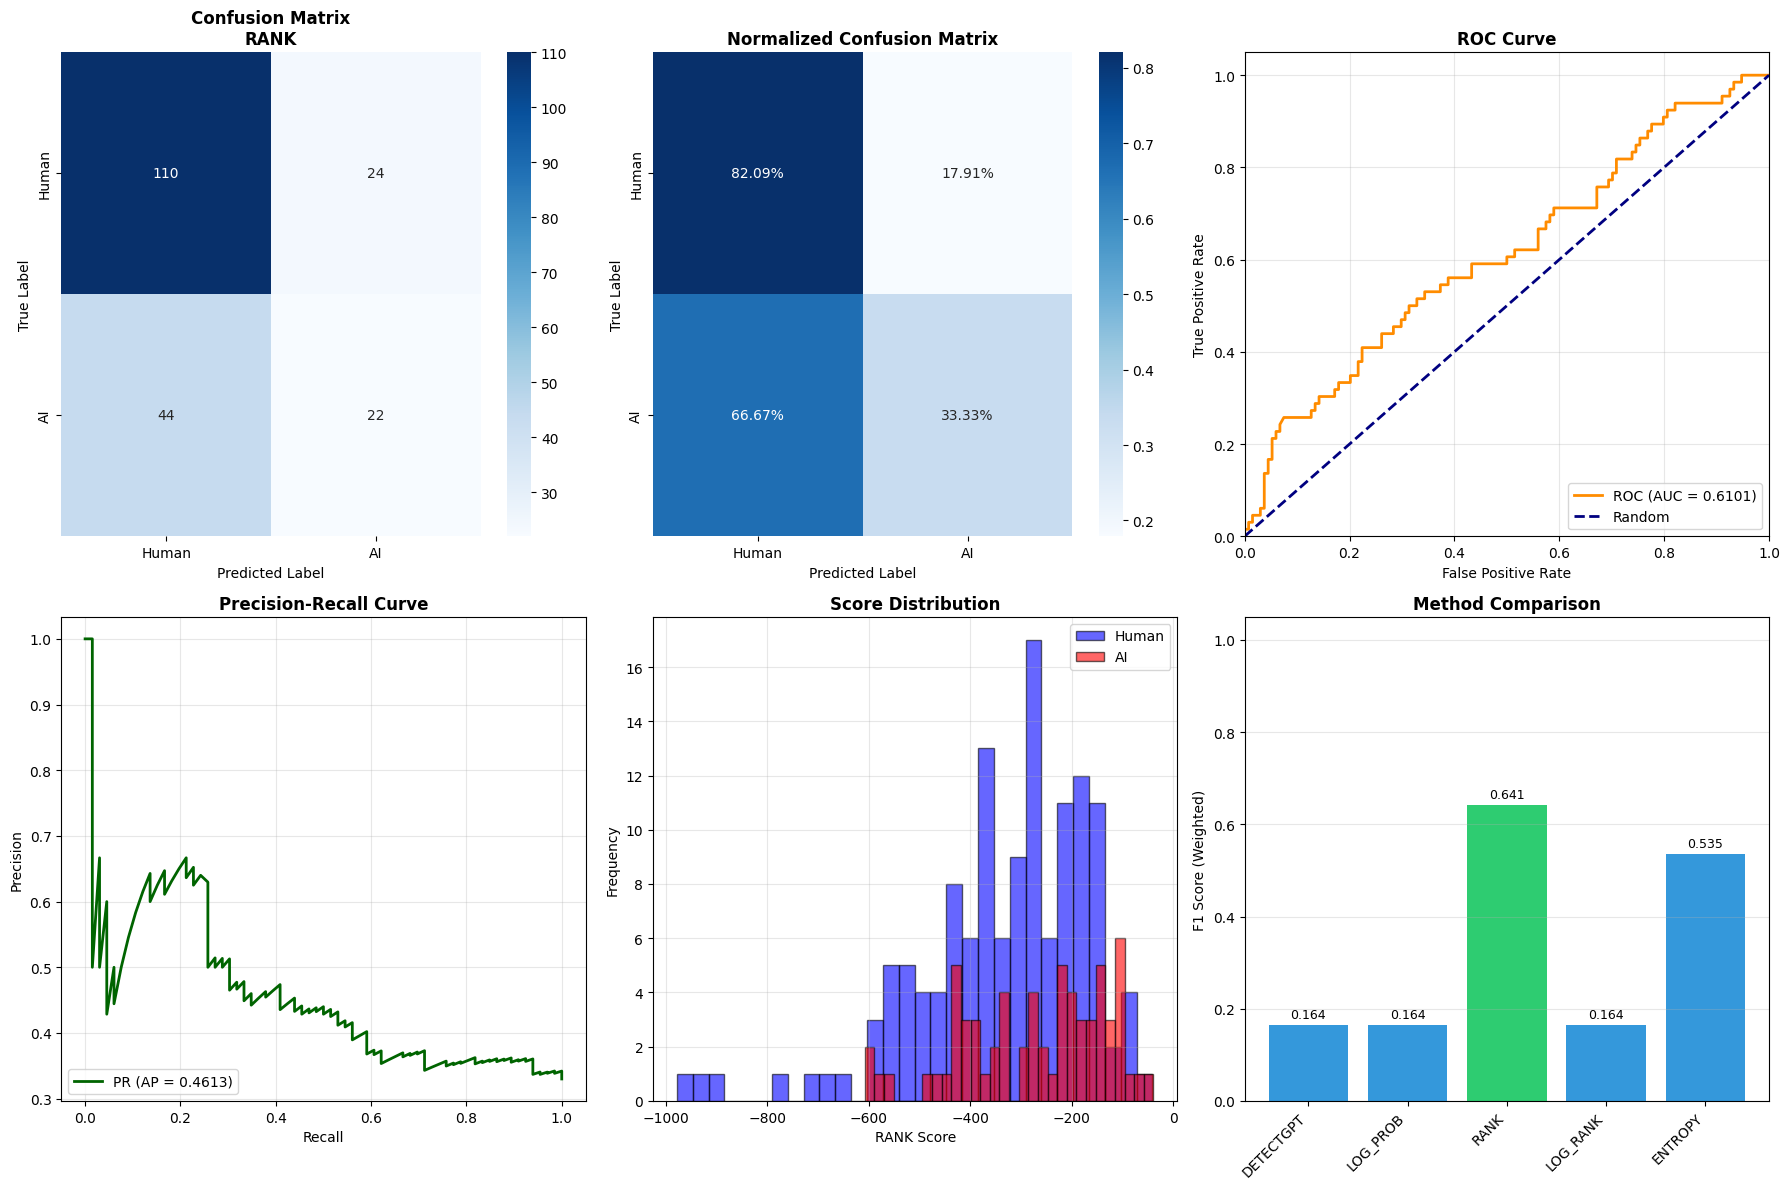

In [10]:
print("📈 Creating visualizations...\n")

best_result = results[best_method]
y_pred = best_result['y_pred']
y_score = best_result['y_score']

fig = plt.figure(figsize=(18, 12))

# 1. Confusion Matrix
ax1 = plt.subplot(2, 3, 1)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Human', 'AI'], yticklabels=['Human', 'AI'])
plt.title(f'Confusion Matrix\n{best_method.upper()}', fontsize=12, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

# 2. Normalized Confusion Matrix
ax2 = plt.subplot(2, 3, 2)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=['Human', 'AI'], yticklabels=['Human', 'AI'])
plt.title('Normalized Confusion Matrix', fontsize=12, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

# 3. ROC Curve
ax3 = plt.subplot(2, 3, 3)
fpr, tpr, _ = roc_curve(y_test, y_score)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve', fontsize=12, fontweight='bold')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

# 4. Precision-Recall Curve
ax4 = plt.subplot(2, 3, 4)
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_score)
avg_precision = average_precision_score(y_test, y_score)
plt.plot(recall_vals, precision_vals, color='darkgreen', lw=2, 
         label=f'PR (AP = {avg_precision:.4f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve', fontsize=12, fontweight='bold')
plt.legend(loc="lower left")
plt.grid(alpha=0.3)

# 5. Score Distribution
ax5 = plt.subplot(2, 3, 5)
human_scores = y_score[np.array(y_test) == 0]
ai_scores = y_score[np.array(y_test) == 1]
plt.hist(human_scores, bins=30, alpha=0.6, label='Human', color='blue', edgecolor='black')
plt.hist(ai_scores, bins=30, alpha=0.6, label='AI', color='red', edgecolor='black')
plt.xlabel(f'{best_method.upper()} Score')
plt.ylabel('Frequency')
plt.title('Score Distribution', fontsize=12, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)

# 6. Method Comparison
ax6 = plt.subplot(2, 3, 6)
method_names = list(results.keys())
f1_scores = [results[m]['f1_weighted'] for m in method_names]
colors = ['#2ecc71' if m == best_method else '#3498db' for m in method_names]

bars = plt.bar(range(len(method_names)), f1_scores, color=colors)
plt.xticks(range(len(method_names)), [m.upper() for m in method_names], rotation=45, ha='right')
plt.ylabel('F1 Score (Weighted)')
plt.title('Method Comparison', fontsize=12, fontweight='bold')
plt.ylim([0, 1.05])
plt.grid(axis='y', alpha=0.3)

for i, (bar, score) in enumerate(zip(bars, f1_scores)):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{score:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('detectgpt_evaluation.png', dpi=300, bbox_inches='tight')
plt.show()


In [11]:
print(f"\n📋 Classification Report ({best_method.upper()}):")
print(classification_report(y_test, y_pred, target_names=['Human', 'AI'], digits=4))



📋 Classification Report (RANK):
              precision    recall  f1-score   support

       Human     0.7143    0.8209    0.7639       134
          AI     0.4783    0.3333    0.3929        66

    accuracy                         0.6600       200
   macro avg     0.5963    0.5771    0.5784       200
weighted avg     0.6364    0.6600    0.6414       200



In [12]:
print("\n📊 All Methods - Results Summary:")

comparison_df = pd.DataFrame({
    'Method': [m.upper() for m in results.keys()],
    'Accuracy': [results[m]['accuracy'] for m in results.keys()],
    'F1 (Weighted)': [results[m]['f1_weighted'] for m in results.keys()],
    'F1 (Human)': [results[m]['f1_human'] for m in results.keys()],
    'F1 (AI)': [results[m]['f1_ai'] for m in results.keys()],
    'Precision': [results[m]['precision'] for m in results.keys()],
    'Recall': [results[m]['recall'] for m in results.keys()],
    'AUC-ROC': [results[m]['auc_roc'] for m in results.keys()],
    'PR-AUC': [results[m]['pr_auc'] for m in results.keys()]
})

print(comparison_df.to_string(index=False))

comparison_df.to_csv('detectgpt_comparison.csv', index=False)
print("\n💾 Results saved to 'detectgpt_comparison.csv'")


📊 All Methods - Results Summary:
   Method  Accuracy  F1 (Weighted)  F1 (Human)  F1 (AI)  Precision  Recall  AUC-ROC   PR-AUC
DETECTGPT     0.330       0.163759    0.000000 0.496241   0.108900   0.330 0.776346 0.601986
 LOG_PROB     0.330       0.163759    0.000000 0.496241   0.108900   0.330 0.788218 0.693283
     RANK     0.660       0.641448    0.763889 0.392857   0.636398   0.660 0.610075 0.461293
 LOG_RANK     0.330       0.163759    0.000000 0.496241   0.108900   0.330 0.775780 0.683933
  ENTROPY     0.665       0.535195    0.798799 0.000000   0.447789   0.665 0.244573 0.228845

💾 Results saved to 'detectgpt_comparison.csv'


In [13]:
detailed_results = {
    'approach': 'DetectGPT (Zero-Shot Probability Curvature)',
    'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'config': {
        'sample_size': config.SAMPLE_SIZE,
        'test_size': config.TEST_SIZE,
        'mask_filling_model': config.MASK_FILLING_MODEL,
        'scoring_model': config.SCORING_MODEL,
        'num_perturbations': config.NUM_PERTURBATIONS,
        'mask_rate': config.MASK_RATE,
        'span_length': config.SPAN_LENGTH
    },
    'dataset_info': {
        'train_size': len(X_train),
        'val_size': len(X_val),
        'test_size': len(X_test)
    },
    'best_method': {
        'name': best_method,
        'metrics': {
            'accuracy': float(results[best_method]['accuracy']),
            'f1_weighted': float(results[best_method]['f1_weighted']),
            'f1_human': float(results[best_method]['f1_human']),
            'f1_ai': float(results[best_method]['f1_ai']),
            'precision': float(results[best_method]['precision']),
            'recall': float(results[best_method]['recall']),
            'auc_roc': float(results[best_method]['auc_roc']),
            'pr_auc': float(results[best_method]['pr_auc'])
        }
    },
    'all_methods': {
        name: {
            'accuracy': float(res['accuracy']),
            'f1_weighted': float(res['f1_weighted']),
            'auc_roc': float(res['auc_roc'])
        }
        for name, res in results.items()
    },
    'confusion_matrix': cm.tolist()
}

with open(config.RESULTS_FILE, 'w') as f:
    json.dump(detailed_results, f, indent=2)

print(f"💾 Detailed results saved to '{config.RESULTS_FILE}'")


💾 Detailed results saved to 'detectgpt_results.json'



🔍 Analyzing perturbation discrepancy distribution...


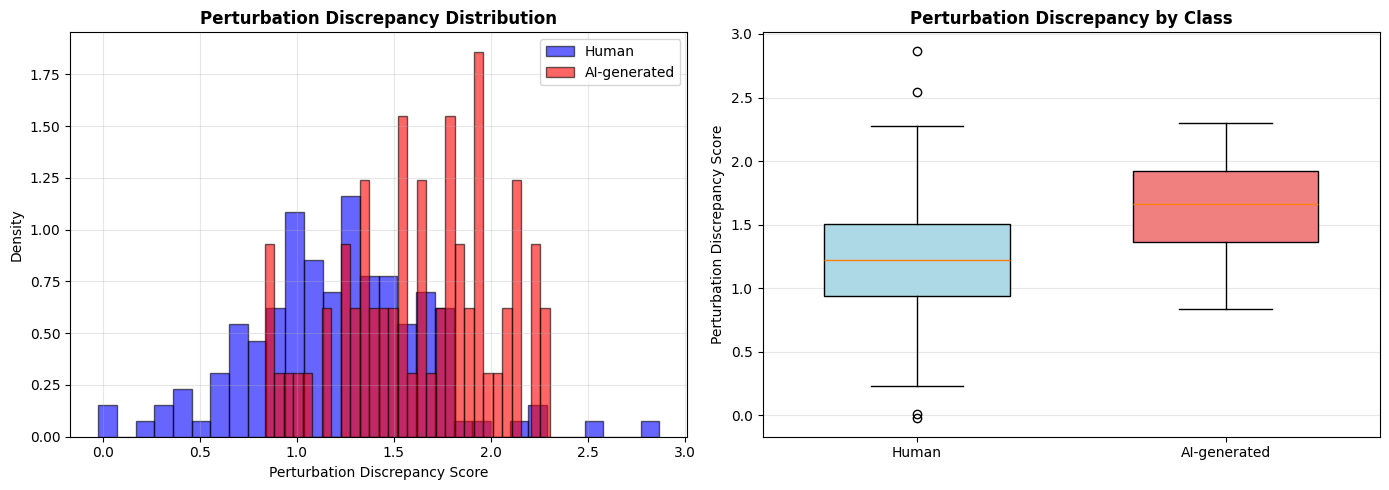


Perturbation Discrepancy Statistics:
Human - Mean: 1.2014, Std: 0.4638
AI    - Mean: 1.6434, Std: 0.3850
Gap: 0.4420


In [14]:
print("\n🔍 Analyzing perturbation discrepancy distribution...")

# Show distribution of perturbation discrepancy for human vs AI
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Separate human and AI texts
detectgpt_scores = test_scores['detectgpt']
human_discrepancy = detectgpt_scores[np.array(y_test) == 0]
ai_discrepancy = detectgpt_scores[np.array(y_test) == 1]

# Plot 1: Histogram
axes[0].hist(human_discrepancy, bins=30, alpha=0.6, label='Human', 
             color='blue', edgecolor='black', density=True)
axes[0].hist(ai_discrepancy, bins=30, alpha=0.6, label='AI-generated', 
             color='red', edgecolor='black', density=True)
axes[0].set_xlabel('Perturbation Discrepancy Score')
axes[0].set_ylabel('Density')
axes[0].set_title('Perturbation Discrepancy Distribution', fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Plot 2: Box plot
data_to_plot = [human_discrepancy, ai_discrepancy]
bp = axes[1].boxplot(data_to_plot, labels=['Human', 'AI-generated'], 
                      patch_artist=True, widths=0.6)
bp['boxes'][0].set_facecolor('lightblue')
bp['boxes'][1].set_facecolor('lightcoral')
axes[1].set_ylabel('Perturbation Discrepancy Score')
axes[1].set_title('Perturbation Discrepancy by Class', fontweight='bold')
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('perturbation_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nPerturbation Discrepancy Statistics:")
print(f"Human - Mean: {np.mean(human_discrepancy):.4f}, Std: {np.std(human_discrepancy):.4f}")
print(f"AI    - Mean: {np.mean(ai_discrepancy):.4f}, Std: {np.std(ai_discrepancy):.4f}")
print(f"Gap: {np.mean(ai_discrepancy) - np.mean(human_discrepancy):.4f}")


In [15]:
print("\n📝 Generating sample perturbations for visualization...")

# Take a few sample texts and show their perturbations
sample_indices = [0, 1]  # First human and first AI text
sample_data = []

for idx in sample_indices:
    text = X_test[idx]
    label = "AI-generated" if y_test[idx] == 1 else "Human-written"
    
    # Generate perturbations
    perturbations = generate_perturbations(
        text[:200], 5,  # Use first 200 chars, 5 perturbations
        mask_model, mask_tokenizer, device
    )
    
    # Get scores
    orig_score = get_log_probability(text[:200], score_model, 
                                     score_tokenizer, device, config.MAX_LENGTH)
    pert_scores = [get_log_probability(p, score_model, score_tokenizer, 
                                       device, config.MAX_LENGTH) 
                   for p in perturbations]
    
    sample_data.append({
        'original': text[:200],
        'label': label,
        'orig_score': orig_score,
        'perturbations': perturbations,
        'pert_scores': pert_scores,
        'discrepancy': orig_score - np.mean(pert_scores)
    })

# Save sample perturbations
with open(config.PERTURBATIONS_FILE, 'w') as f:
    json.dump(sample_data, f, indent=2)

print(f"💾 Sample perturbations saved to '{config.PERTURBATIONS_FILE}'")

# Display samples
for i, sample in enumerate(sample_data):
    print(f"\n{'='*80}")
    print(f"Sample {i+1}: {sample['label']}")
    print(f"{'='*80}")
    print(f"Original text: {sample['original'][:100]}...")
    print(f"Original log p(x): {sample['orig_score']:.4f}")
    print(f"Mean perturbed log p(x): {np.mean(sample['pert_scores']):.4f}")
    print(f"Discrepancy: {sample['discrepancy']:.4f}")
    print(f"\nSample perturbation: {sample['perturbations'][0][:100]}...")



📝 Generating sample perturbations for visualization...
💾 Sample perturbations saved to 'perturbations_sample.json'

Sample 1: Human-written
Original text: the seagoing cowboys were having some of the best times of their life luke is a seagoing cowboy doin...
Original log p(x): -4.6388
Mean perturbed log p(x): -4.8986
Discrepancy: 0.2598

Sample perturbation: the seagoing cowboys were having some of the best times of their life luke is a seagoing cowboy doin...

Sample 2: Human-written
Original text: each day in the united states approximately 9 people are killed and more than 1000 injures in crashe...
Original log p(x): -4.2031
Mean perturbed log p(x): -4.3190
Discrepancy: 0.1159

Sample perturbation: have been killed in the united states approximately 9 people have died, and more than 1000 injures i...


In [16]:
def predict_text(text, return_all_scores=False):
    """
    Predict if text is AI-generated using DetectGPT
    
    Args:
        text: Input text string
        return_all_scores: If True, returns dict with all method scores
    
    Returns:
        Label or dict with scores
    """
    # Compute DetectGPT score
    detectgpt_score = compute_detectgpt_score(
        text, score_model, score_tokenizer,
        mask_model, mask_tokenizer, device,
        config.NUM_PERTURBATIONS
    )
    
    # Simple threshold (you can tune this on validation set)
    threshold = 0.0
    prediction = "AI-generated" if detectgpt_score > threshold else "Human-written"
    
    if return_all_scores:
        # Compute baseline scores
        log_p = get_log_probability(text, score_model, score_tokenizer, 
                                    device, config.MAX_LENGTH)
        rank, log_rank = get_token_ranks(text, score_model, score_tokenizer, 
                                        device, config.MAX_LENGTH)
        entropy = get_entropy(text, score_model, score_tokenizer, 
                             device, config.MAX_LENGTH)
        
        return {
            'prediction': prediction,
            'detectgpt_score': detectgpt_score,
            'log_probability': log_p,
            'rank': rank,
            'log_rank': log_rank,
            'entropy': entropy
        }
    
    return prediction

In [17]:
print("\n💬 Testing inference with DetectGPT:")
test_examples = [
    "Artificial intelligence has revolutionized modern computing with advanced algorithms.",
    "I spent my weekend hiking in the mountains with friends and it was amazing!",
    "The implementation of neural networks requires careful consideration of hyperparameters.",
    "Yesterday I made the best pasta ever. The secret is lots of garlic and fresh basil."
]

for text in test_examples:
    result = predict_text(text, return_all_scores=True)
    print(f"\nText: '{text[:80]}...'")
    print(f"Prediction: {result['prediction']}")
    print(f"DetectGPT Score: {result['detectgpt_score']:.3f}")
    print(f"Log Probability: {result['log_probability']:.3f}")


💬 Testing inference with DetectGPT:

Text: 'Artificial intelligence has revolutionized modern computing with advanced algori...'
Prediction: AI-generated
DetectGPT Score: 1.415
Log Probability: -3.953

Text: 'I spent my weekend hiking in the mountains with friends and it was amazing!...'
Prediction: AI-generated
DetectGPT Score: 0.839
Log Probability: -3.437

Text: 'The implementation of neural networks requires careful consideration of hyperpar...'
Prediction: AI-generated
DetectGPT Score: 0.603
Log Probability: -3.510

Text: 'Yesterday I made the best pasta ever. The secret is lots of garlic and fresh bas...'
Prediction: AI-generated
DetectGPT Score: 0.784
Log Probability: -3.593


In [18]:
print("\n" + "="*80)
print("🎉 DetectGPT Analysis Complete!")
print("="*80)

print(f"\n📊 SUMMARY:")
print(f"Best Detection Method: {best_method.upper()}")
print(f"Test Accuracy: {results[best_method]['accuracy']:.4f}")
print(f"Test F1 Score: {results[best_method]['f1_weighted']:.4f}")
print(f"AUC-ROC: {results[best_method]['auc_roc']:.4f}")
print(f"PR-AUC: {results[best_method]['pr_auc']:.4f}")

print(f"\n🔬 KEY INSIGHTS:")
print(f"1. DetectGPT leverages probability curvature for zero-shot detection")
print(f"2. Uses {config.NUM_PERTURBATIONS} perturbations per text via {config.MASK_FILLING_MODEL}")
print(f"3. Scores text with {config.SCORING_MODEL} language model")
print(f"4. Perturbation discrepancy gap: {np.mean(ai_discrepancy) - np.mean(human_discrepancy):.4f}")

print(f"\n📁 OUTPUT FILES:")
print(f"  - detectgpt_comparison.csv: All methods comparison")
print(f"  - detectgpt_results.json: Detailed results")
print(f"  - detectgpt_evaluation.png: Visualizations")
print(f"  - perturbation_analysis.png: Discrepancy distributions")
print(f"  - perturbations_sample.json: Sample perturbations")

print("\n" + "="*80)


🎉 DetectGPT Analysis Complete!

📊 SUMMARY:
Best Detection Method: RANK
Test Accuracy: 0.6600
Test F1 Score: 0.6414
AUC-ROC: 0.6101
PR-AUC: 0.4613

🔬 KEY INSIGHTS:
1. DetectGPT leverages probability curvature for zero-shot detection
2. Uses 25 perturbations per text via t5-small
3. Scores text with gpt2 language model
4. Perturbation discrepancy gap: 0.4420

📁 OUTPUT FILES:
  - detectgpt_comparison.csv: All methods comparison
  - detectgpt_results.json: Detailed results
  - detectgpt_evaluation.png: Visualizations
  - perturbation_analysis.png: Discrepancy distributions
  - perturbations_sample.json: Sample perturbations




📊 Creating cross-method comparison matrix...


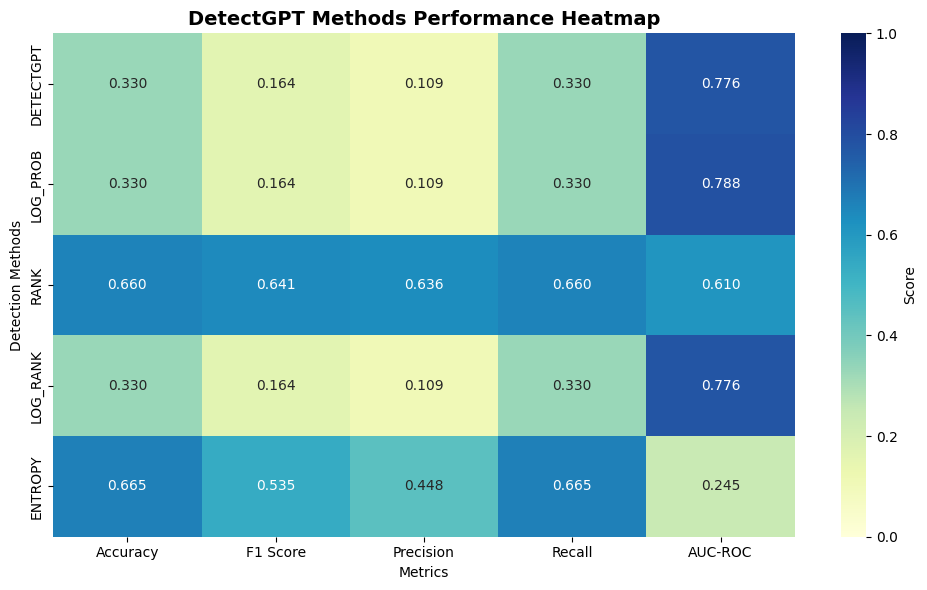

✅ Comparison matrix created and saved!

✨ All analyses complete! Ready for comparison with other approaches.


In [20]:
print("\n📊 Creating cross-method comparison matrix...")

# Compare all three approaches if results exist
comparison_approaches = {
    'DetectGPT': results[best_method]['f1_weighted'],
}

# Create comparison visualization
fig, ax = plt.subplots(figsize=(10, 6))

methods = list(results.keys())
metrics = ['Accuracy', 'F1 Score', 'Precision', 'Recall', 'AUC-ROC']
scores_matrix = []

for method in methods:
    scores_matrix.append([
        results[method]['accuracy'],
        results[method]['f1_weighted'],
        results[method]['precision'],
        results[method]['recall'],
        results[method]['auc_roc']
    ])

scores_df = pd.DataFrame(scores_matrix, 
                         columns=metrics, 
                         index=[m.upper() for m in methods])

sns.heatmap(scores_df, annot=True, fmt='.3f', cmap='YlGnBu', 
            vmin=0, vmax=1, cbar_kws={'label': 'Score'})
plt.title('DetectGPT Methods Performance Heatmap', fontsize=14, fontweight='bold')
plt.xlabel('Metrics')
plt.ylabel('Detection Methods')
plt.tight_layout()
plt.savefig('detectgpt_methods_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Comparison matrix created and saved!")

print("\n" + "="*80)
print("✨ All analyses complete! Ready for comparison with other approaches.")
print("="*80)